#**Assignment 3: Fine-Tuning** (***Due date: October 21, 2025***)
# Overview
## Total [100 Points]
In this assignment, you will fine-tune a pretrained CNN to classify images from a variety of natural scenes around the world. The dataset contains 6 different categories (more on that later). You will load and transform the data, then instantiate a pre-trained model to fine-tune. After that you will extract image features using your model and visualize the results with t-SNE.

### Submission:
You will need to submit the following to Canvas:  
1. your notebook.ipynb (with all the outputs shown)

# Setting up

We'll start by importing some dependancies, You have seen most of these from the previouse assignment. The most notable additions are:
- [`models`](https://pytorch.org/vision/stable/models.html) - Subpackage containing definitions of models for addressing different tasks along with their pretrained weights (sometimes different varients trained on different datasets can be found).
- [`TSNE`](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) - An API from the `sklearn` package that provides a convenient way to use t-SNE visualization

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import time
import copy
import os

# Check if GPU is available
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data
- Number of classes: 6 ('buildings', 'forest', 'glacier', 'mountain', 'sea', 'street')
- Total images: ~17k
- Image format: RGB images in JPG format
- Image dimensions: 150x150
- Dataset structure:
```
intel/
├──seg_train/
|  ├── buildings/
|  ├── forest/
|  ├── glacier/
|  ├── mountain/
|  ├── sea/
|  └── street/
└──seg_test/
     ├── buildings/
     ├── forest/
     ├── glacier/
     ├── mountain/
     ├── sea/
     └── street/
```

**Important Note!**

In this assignment, you are given access to the entire dataset. You only have a training and a test split. You should know that it is always recommended to report your model performance on an unseen test dataset. For the purpose of this assignment only, we will treat the test split as the validation split.

## Pre-processing

### Part 1: Data Transforms [20 points]

You'll need to define transformations that are applied to the data. You will need to do the following
- Standardize input sizes (224x224 in our case)
- Data augmentation to prevent overfitting (at least horizontal flipping)
- Cast the values to a torch tensor
- Normalize pixel values with ImageNet statistics

**ImageNet Statistics:**

Remember from the last assignment that we normalize our images using ImageNet statistics because it has been shown to improve training. We also have another reason to do this: we will be using weights pretrained on ImageNet, so to have the best performance we would need to normalize the data to follow the same distribution our model has been trained on.
The statistics are:
```
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
```

In [7]:
# Define Data Augmentation and Normalization
train_transforms = transforms.Compose([
    # TODO: Implement training dataset transforms
    # Hint: Train resize/crops should be random
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    # TODO: Implement validation dataset transforms
    # Hint: Val transforms are deterministic and not all transforms of the train split should be applied
    transforms.Resize(256), #Prevent distortion of the image by resizing it slightly bigger
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])

])

## Data Loading

In [4]:
# [Optional] Copy data from the drive to your local session for faster loading
drive_data_dir = '/content/drive/Shareddrives/COSC_3470_Fall25/datasets/intel/'  # Make sure to mount the drive
!cp -r "$drive_data_dir" intel

In [8]:
# Define dataset directory (modify this if needed)
DATA_DIR = "/content/intel"
NUM_CLASSES = 6  # Intel dataset has 6 categories as mentioned

# If you didn't copy the data from the drive, uncomment the following line
# for the dataloader to directly load from the drive
# DATA_DIR = '/content/drive/Shareddrives/COSC_3470_Fall25/datasets/intel/'

# Load Datasets
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "seg_train"), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "seg_test"), transform=val_transforms)

# Define DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Print dataset information
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")

Number of training samples: 13989
Number of validation samples: 2996
Number of classes: 6


In [9]:
for inputs, labels in train_loader:
    print("Inputs shape:", inputs.shape)
    print("Labels shape:", labels.shape)
    break

Inputs shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


# Model
Instead of implementing our own CNN from scratch, we will utilize a model called ResNet pretrained on the ImageNet dataset. `torchvision` provides a convenient API called `models` that contains popular architectures along with multiple pretrained weights for each architecture. We will use one of ResNet's variations called [`resnet18`](https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html) along with the weights set called `IMAGENET1K_V1` from pretraining on ImageNet. For those interested, you can find the paper that introduced the architecture [here](https://arxiv.org/abs/1512.03385).

**Important Note!**

The ResNet model we will be using was trained on ImageNet with 1000 classes so the last layer will have 1000 neurons! Our task on the other hand will require only 6 because we have 6 classes. It is important to change the classification head to match the number of classes of the downstream task we are adapting the model to. We will also only finetune the new classification head, for now, as a basline of how the model performs.


To choose which layer/parameter to freeze you can set the property `requires_grad` to be `False` and set it to `True` for only the ones you want to un-freeze/fine-tune.

In [10]:
# Load Pretrained ResNet-18
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Change classification head
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)  # Replace FC layer
model.fc.requires_grad = True  # Only train the last layer

# Move model to GPU if available
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


# Training

### Part 2: Training loop [20 points]

Implement a training loop to be used to fine-tune your model. This follows the same training process used in the previous assignment.

In [11]:
LEARNING_RATE = 0.001
EVAL_INTERVAL = 50
NUM_EPOCHS = 2

# Define Loss Function and Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

# Training Function with Step Logging
def train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS, eval_interval=EVAL_INTERVAL):
    train_losses, val_accs, eval_steps = [], [], []
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    step = 0

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_loss = 0.0

        for inputs, labels in tqdm(train_loader):
            # TODO: Implement the training loop
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE) #Use GPU
            optimizer.zero_grad() #Zeroing parameters gradients
            outputs = model(inputs) #fwd pass
            loss = criterion(outputs, labels) #loss
            loss.backward() #backward pass
            optimizer.step() #parameter update

            step += 1
            running_loss += loss.item()
            train_losses.append(loss.item())

            # Evaluate model every EVAL_INTERVAL steps during the epoch
            # Unlike last assignment where we evaluated once every epoch
            # It's better to see how the model changes during the epoch, specially with larger datasets
            if step % eval_interval == 0:
                val_acc = evaluate_model(model, val_loader, criterion)
                val_accs.append(val_acc)
                eval_steps.append(step)

                # Save best model
                if val_acc > best_acc:
                    best_acc = val_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

        epoch_loss = running_loss / len(train_loader)
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Training Loss: {epoch_loss:.4f}')
        print(f'Validation Accuracy: {val_acc:.2f}%')

    print(f"Best Val Accuracy: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model, train_losses, val_accs, eval_steps

# Evaluation Function
def evaluate_model(model, val_loader, criterion):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)

    val_acc = correct.double() / total
    return val_acc.item()

In [12]:
# Train the Model
model, train_losses, val_accs, eval_steps = train_model(model, criterion, optimizer)

# Save the fine-tuned model
torch.save(model.state_dict(), "resnet18_finetuned_v1.pth")

100%|██████████| 438/438 [01:44<00:00,  4.20it/s]


Epoch 1/2:
Training Loss: 0.5762
Validation Accuracy: 0.89%


100%|██████████| 438/438 [01:50<00:00,  3.97it/s]


Epoch 2/2:
Training Loss: 0.4019
Validation Accuracy: 0.90%
Best Val Accuracy: 0.8992


In [13]:
# You can use this to plot a graph of your training over time
# It can be useful to check if your model overfits or underfits the data
def plot_training_results(train_losses, val_accs, eval_steps):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot training loss
    ax1.plot(train_losses)
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Training Steps')
    ax1.set_ylabel('Loss')

    # Plot validation accuracy
    ax2.plot(eval_steps, val_accs, marker="o", linestyle="-")
    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Training Steps')
    ax2.set_ylabel('Accuracy (%)')

    plt.tight_layout()
    plt.show()

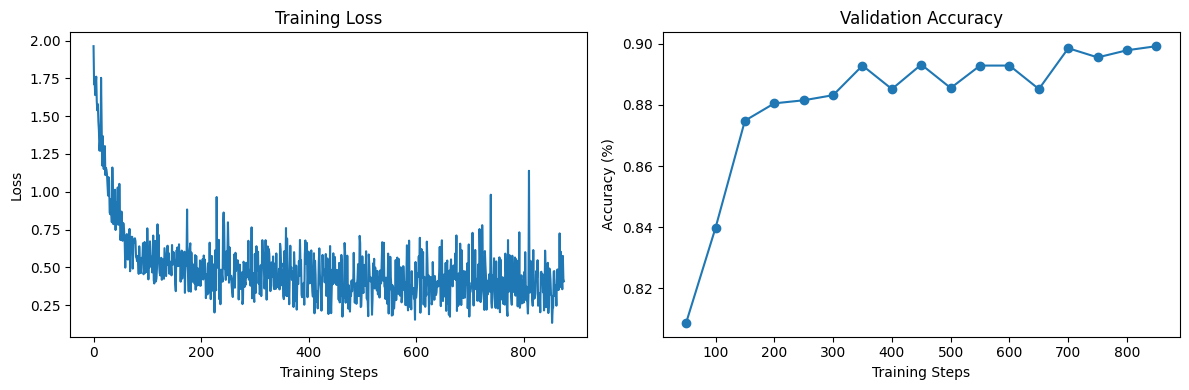

In [14]:
# Plot the results
plot_training_results(train_losses, val_accs, eval_steps)

# Feature Extraction and Visualization

### Part 3: Extracting image features [30 points]

In this part you will do 2 things:
- Build a feature extractor using your trained model. A feature extractor is just your model with the last fully connected layer `fc` removed. An easy way to build it is to start with an empty `sequential` module and add all your model layers except the last one. A good property that will help you iterate your model is [`children`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.children)
- Use this feature extractor to extract image features from the validation dataset to be visualized with t-SNE

In [15]:
# Define a feature extraction model (removes the final classification layer)
def extract_features(model, val_loader):
    # TODO: build the feature extractor
    feature_extractor = nn.Sequential(*list(model.children())[:-1]) #using children to get all layers except last
    feature_extractor.eval() #To disable dropouts or batchnorm by setting to evaluation mode
    feature_extractor.to(DEVICE)
    # Extract features and labels
    features, labels = [], []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(DEVICE)
            # TODO: Extract features for the inputs
            # 1. pass the inputs to the feature extractor to get feature maps
            feature_maps = feature_extractor(inputs)
            # 2. Get a flattened view to (batch_size, feature_dim)
            output = feature_maps.view(inputs.size(0), -1)

            features.append(output.cpu().numpy())
            labels.append(targets.numpy())

    # Convert to NumPy arrays
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)

    return features, labels

In [16]:
# Extract features and labels
features, labels = extract_features(model, val_loader)

In [17]:
def visualize_features(features, labels):
    # Apply t-SNE for dimensionality reduction
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    features_2d = tsne.fit_transform(features)

    # Plot the t-SNE visualization
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap="jet", alpha=0.7)
    plt.colorbar(scatter, ticks=range(6), label="Class Labels")
    plt.title("t-SNE Visualization of ResNet-18 Extracted Features")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

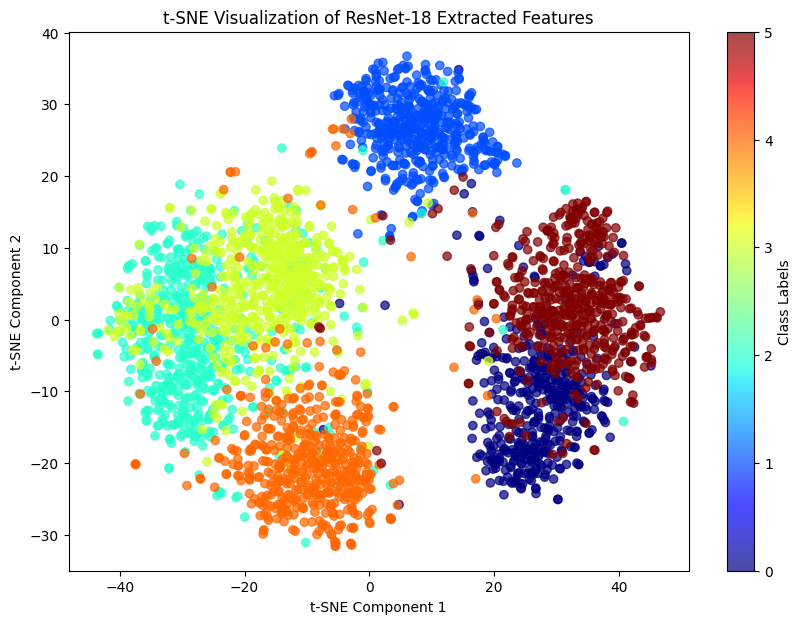

In [18]:
# Visualize the extracted features into a lower 2-diminsional space
visualize_features(features, labels)

# More Fine-Tuning

### Part 4: Fine-Tuning ResNet [30 points]

So far, we have only fine-tuned the last classifier layer and kept the entire model frozen. In practice, it is better to try several configurations where you unfreeze the last n layers of the model. For now you are only required to unfreeze (fine-tune) the last residual layer (last layer before the `fc` layer) in addition to the `fc` layer. You can check the entire architecture of the model using `print(model)`. You can also get an iterator over a certain layer's parameters using the syntax `model.[layer_name].parameters` similar to how we got all model parameters before.


In [19]:
# Load Pretrained ResNet-18 again
model = models.resnet18(weights='IMAGENET1K_V1')

# TODO: Setup the model for fine-tuning
# 1. Freeze all layers
for param in model.parameters():
    param.requires_grad = False
# 2. Un-freeze the last layer (when you print the model architecture you will find it called layer 4)
for param in model.layer4.parameters():
    param.requires_grad = True
# 3. Replace the fc layer with a new classifier with the correct number of calsses
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
# 4. Un-freeze the fc classifier layer
for param in model.fc.parameters():
    param.requires_grad = True

# Move model to GPU if available
model = model.to(DEVICE)

# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [20]:
# Train the new Model (preferably keeping the same configuration for comparison)
model, train_losses, val_accs, eval_steps = train_model(model, criterion, optimizer)

# Save the fine-tuned model
torch.save(model.state_dict(), "resnet18_finetuned_v2.pth")

100%|██████████| 438/438 [01:43<00:00,  4.25it/s]


Epoch 1/2:
Training Loss: 0.4987
Validation Accuracy: 0.90%


100%|██████████| 438/438 [01:52<00:00,  3.89it/s]


Epoch 2/2:
Training Loss: 0.3829
Validation Accuracy: 0.89%
Best Val Accuracy: 0.9219


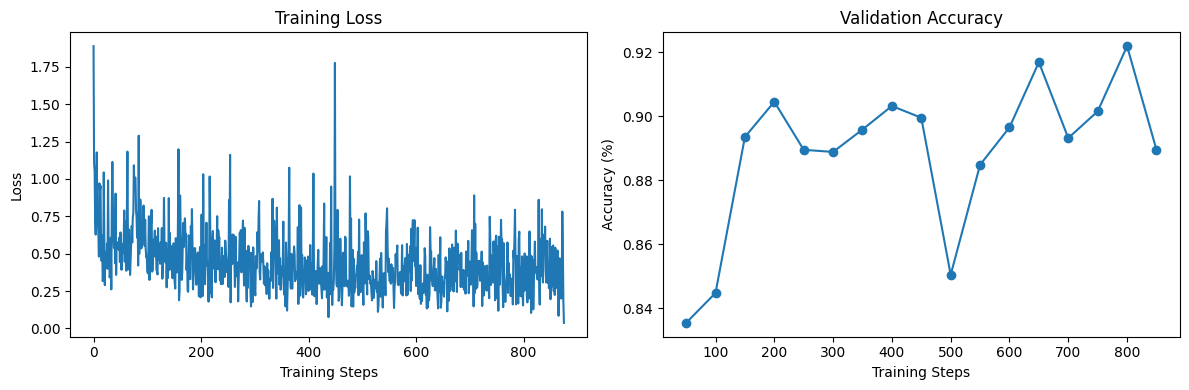

In [21]:
# Plot the results
plot_training_results(train_losses, val_accs, eval_steps)

In [22]:
# Extract features and labels
features, labels = extract_features(model, val_loader)

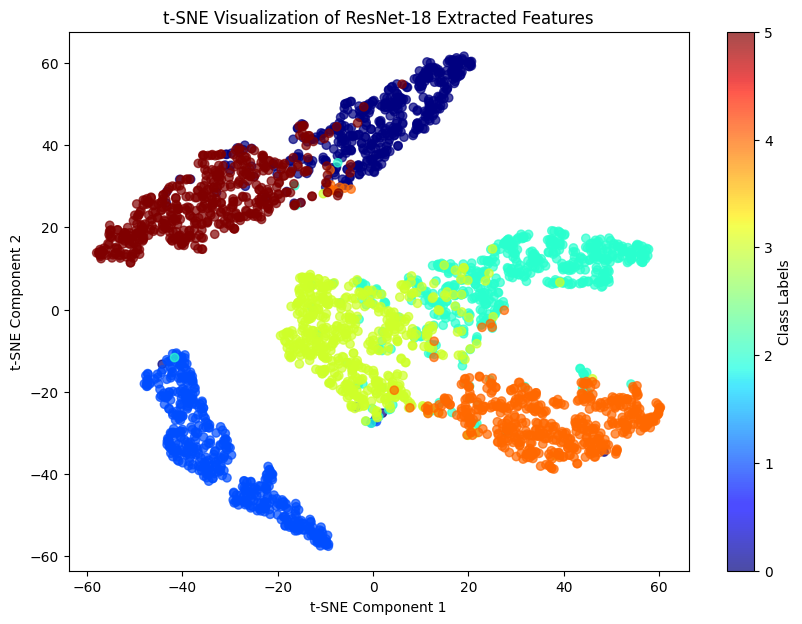

In [23]:
# Visualize the extracted features from the new model
visualize_features(features, labels)

If all goes well, you should notice more separation of classes in the v2 model for the same number of epochs, hence the higher accuracy.